In [9]:
import pandas as pd

df = pd.read_csv('application_data.csv')

In [3]:
# df1 = df.dropna()
# df = df1.dropna(axis=1)

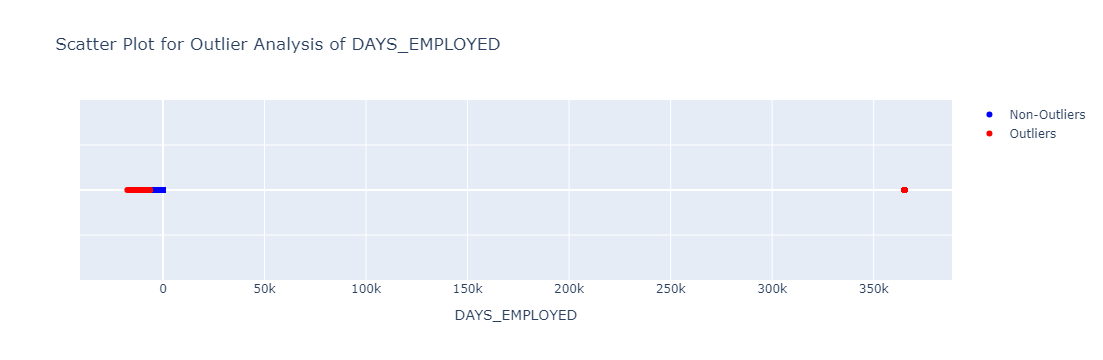

In [13]:
import plotly.express as px
import plotly.graph_objects as go
column_name = 'DAYS_EMPLOYED'

Q1 = df[column_name].quantile(0.25)
Q3 = df[column_name].quantile(0.75)
IQR = Q3 - Q1

lower_threshold = Q1 - 1.5 * IQR
upper_threshold = Q3 + 1.5 * IQR

df['Outlier'] = (df[column_name] < lower_threshold) | (df[column_name] > upper_threshold)

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=df.loc[~df['Outlier'], column_name],
    y=[0] * len(df.loc[~df['Outlier'], column_name]),
    mode='markers',
    name='Non-Outliers',
    marker=dict(color='blue')
))
fig.add_trace(go.Scatter(
    x=df.loc[df['Outlier'], column_name],
    y=[0] * len(df.loc[df['Outlier'], column_name]),
    mode='markers',
    name='Outliers',
    marker=dict(color='red')
))
fig.update_layout(
    title=f'Scatter Plot for Outlier Analysis of {column_name}',
    xaxis_title=column_name,
    yaxis=dict(showticklabels=False)  # Hide y-axis labels
)
fig.show()

TARGET
0    45973
1     4026
Name: count, dtype: int64
TARGET
0    0.919478
1    0.080522
Name: count, dtype: float64


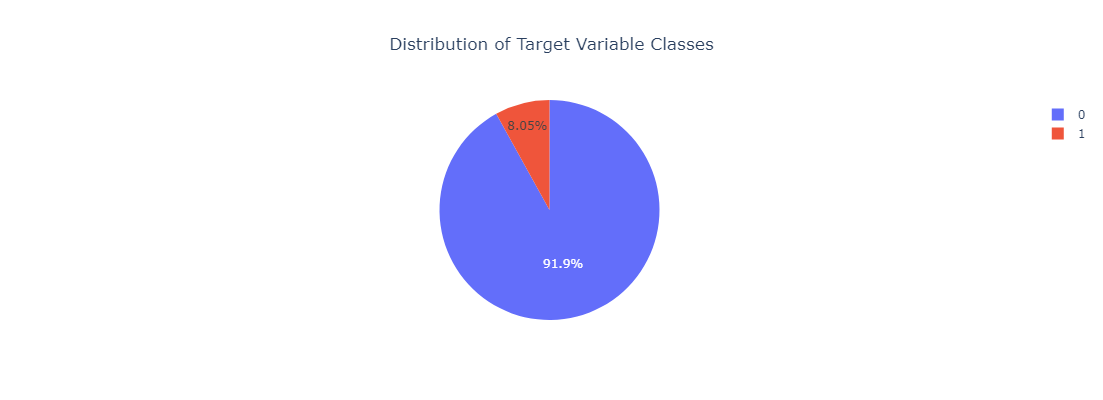

In [17]:
# Calculate class counts
class_counts = df['TARGET'].value_counts()
print(class_counts)

# total count
total_count = df['TARGET'].count()

# Calculate proportions
class_proportions = class_counts / total_count
print(class_proportions)


# pie chart
fig = px.pie(
    names=class_proportions.index,
    values=class_proportions.values,
    title='Distribution of Target Variable Classes'
)

fig.update_layout(
    autosize=False,
    width=400,   # Width of the figure
    height=400,  # Height of the figure (same as width for square shape)
    title=dict(
        text='Distribution of Target Variable Classes',
        x=0.5,  # Center title
        xanchor='center'
    )
)
fig.show()


In [33]:
# Calculate correlations with the target variable
df = df.drop('Cash loans', axis=1, errors='ignore')
correlations = df.corr()['TARGET'].sort_values(ascending=False)
print(correlations.head(10))
print(correlations.tail(10))

# Plot heatmap of correlations
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), cmap='coolwarm', annot=False)
plt.title('Correlation Heatmap')
plt.show()

ValueError: could not convert string to float: 'Cash loans'